# TP0 IMBALANCED DATA MLOPs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


DATA_PATH = "data/bot_iot.csv"

## Question 1

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)

## Question 2

In [3]:
df.shape

(668522, 46)

## Question 3

In [4]:
df["subcategory"].unique().size

6

## Question 4

In [5]:
df["subcategory"].value_counts()

subcategory
UDP                  576884
Service_Scan          73168
OS_Fingerprint        17914
Normal                  477
Keylogging               73
Data_Exfiltration         6
Name: count, dtype: int64

## Question 5

In [6]:
df.columns.tolist()

['pkSeqID',
 'stime',
 'flgs',
 'flgs_number',
 'proto',
 'proto_number',
 'saddr',
 'sport',
 'daddr',
 'dport',
 'pkts',
 'bytes',
 'state',
 'state_number',
 'ltime',
 'seq',
 'dur',
 'mean',
 'stddev',
 'sum',
 'min',
 'max',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'srate',
 'drate',
 'TnBPSrcIP',
 'TnBPDstIP',
 'TnP_PSrcIP',
 'TnP_PDstIP',
 'TnP_PerProto',
 'TnP_Per_Dport',
 'AR_P_Proto_P_SrcIP',
 'AR_P_Proto_P_DstIP',
 'N_IN_Conn_P_DstIP',
 'N_IN_Conn_P_SrcIP',
 'AR_P_Proto_P_Sport',
 'AR_P_Proto_P_Dport',
 'Pkts_P_State_P_Protocol_P_DestIP',
 'Pkts_P_State_P_Protocol_P_SrcIP',
 'attack',
 'category',
 'subcategory']

## Question 6

In [7]:
df.isna().sum()

pkSeqID                             0
stime                               0
flgs                                0
flgs_number                         0
proto                               0
proto_number                        0
saddr                               0
sport                               0
daddr                               0
dport                               0
pkts                                0
bytes                               0
state                               0
state_number                        0
ltime                               0
seq                                 0
dur                                 0
mean                                0
stddev                              0
sum                                 0
min                                 0
max                                 0
spkts                               0
dpkts                               0
sbytes                              0
dbytes                              0
rate        

## Question 7
no missing values to treat them, but this will not harm

In [8]:
df.dropna(inplace=True)

## Question 8

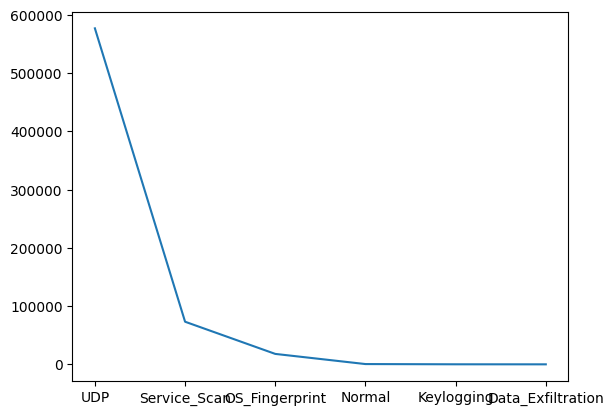

In [9]:
plt.plot(df["subcategory"].value_counts())
plt.show()

## Question 9
an imbalanced dataset if not treated, causes the model to be biased towards the well represented classes and marginalize the minority classes.

## Question 10
treating imbalanced datasets helps the model pay attention to all present classes in an equivalent way which results of better classification performance.

## Question 11
training a model over an imbalanced data makes it biased to the majority class, which leads to considering the minority class as less important, thus predicting the majority class often than expected.

## Question 12
Accuracy is a metric that measures the error over the model's overall performance, it's the cardinal of the correctly classified samples divided by the number of predictions we made.

Context of imbalanced data: when the data is imbalanced, accuracy does not give a real view about the model's performance, for example, if we have a data that is 90% of class A, then having a model that only predicts class A will give us an accuracy of 0.9, which looks great, but in reality, this model is useless.

## Question 13
- **Precision**: when false positives are expensive (e.g. spam detection)
- **Recall**: when false negatives are expensive (e.g. cancer detection)
- **F1-score**: general metric that combines both precision and recall
- **ROC-AUC**: model's ability to distinguish between classes
- **MCC**: best for imbalanced data

## Question 14
Precision: is a metric that calculates the model's ability of positive predictions. It's the ratio of true positives over all positives: `P = TP / (TP + FP)`. It's mainly used when false positives are expensive, so we want to minimize them, for example, classifying a business email as spam (false positive) is too expensive.

## Question 15
Recall: is a metric that evaluates how many of positive cases did we find. It's the ratio of true positives over relevant cases: `R = TP / (TP + FN)`. It's crucial when false negatives are expensive (for example detecting cancer cases).

## Question 16
F1 score: is a metric that presents a balance between precision and recall, providing a balanced performance measure. It's the harmonic mean between precision and recall: `F1 = (2 * precision * recall) / (precision + recall)`

## Question 17
ROC: is a curve that plots true positive rate (sensitivity) against false positive rate (specificity) across different thresholds.

AUC: is the area under this curve, it indicates the model's ability to separate the positive class from the negative one.

## Question 18
- **sensitivity**: it's the same as recall, just a different name
- **specificity**: it's the model's ability to reject true negatives (of all actual negatives, how many did we reject correctly). `specificity = TN / (TN + FP)`

## Question 19
ROC curve is built by plotting sensitivity against specificity for all probability thresholds from 0 to 1, then the AUC is calculated using the Trapezoidal rule under the curve.

## Question 20
accuracy gives an idea of the performance of the model regardless of the classes, which is bad for imbalanced data. F1-score is a combination of precision and recall which makes it more suitable for imbalanced data classification.

## Questions 21 - 27
preprocessing data:

- drop IDs and IPs to avoid data leakage, we also drop `category` and `subcategory` to perform only binary classification
- the target column is `attack`
- split BEFORE scaling to avoid data leakage — the scaler is fitted only on `X_train` and applied to both sets

In [10]:
df.drop_duplicates(inplace=True)

# drop ids and ips to avoid data leakage, we also drop category and subcategory to perform only binary classif
# the target column is attack
cols_to_drop = [
    "pkSeqID",        # ID
    "seq",            # ID-like / sequential
    "stime",          # raw timestamp
    "ltime",          # raw timestamp
    "saddr",          # source IP (leakage)
    "daddr",          # dest IP (leakage)
    "category",
    "subcategory",
    "TnBPSrcIP",
    "TnBPDstIP",
    "TnP_PSrcIP",
    "TnP_PDstIP",
    "TnP_PerProto",
    "TnP_Per_Dport",
    "AR_P_Proto_P_SrcIP",
    "AR_P_Proto_P_DstIP",
    "N_IN_Conn_P_DstIP",
    "N_IN_Conn_P_SrcIP",
    "AR_P_Proto_P_Sport",
    "AR_P_Proto_P_Dport",
    "Pkts_P_State_P_Protocol_P_DestIP",
    "Pkts_P_State_P_Protocol_P_SrcIP",
    "rate", "srate", "drate", "pkts", "bytes"
]
df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

df['sport'] = pd.to_numeric(df['sport'], errors='coerce')
df['dport'] = pd.to_numeric(df['dport'], errors='coerce')
df.dropna(inplace=True)

# one hot encoding categ columns
categ_cols = ['proto', 'state', 'flgs']
df = pd.get_dummies(df, columns=categ_cols, drop_first=True)

y = df['attack']
X = df.drop(columns=["attack"])

# split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=24, test_size=0.2)

# scale after split, fitted only on X_train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # for roc-auc

    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba)
    }


MODELS = [LogisticRegression(), SVC(probability=True), RandomForestClassifier()]

metrics_original = []
for model in MODELS:
    metrics_original.append(train_and_evaluate(model, X_train, X_test, y_train, y_test))

print("original data:")
print(pd.DataFrame(metrics_original, index=["logistic regression", "SVMC", "random forest"]))

original data:
                     accuracy  precision    recall  F1-score   ROC-AUC
logistic regression  0.999689   0.999727  0.999962  0.999844  0.991804
SVMC                 0.999712   0.999742  0.999970  0.999856  0.993948
random forest        0.999955   0.999985  0.999970  0.999977  0.999998


these results are weird, because I am almost certain that there is no data leakage. this might be explained by the fact that the data is highly imbalanced. so the model is not generalizing, but it always predicts the dominant class.

## Question 29 & 30
NOTE: We should only apply sampling techniques to training data

Synthetic Minority Over-Sampling TEchnique: for each minority class sample, it selects one of its k-nearest neighbors from the same class and interpolates a new data sample from the original sample and the selected neighbor.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

MODELS = [LogisticRegression(max_iter=300), SVC(probability=True, kernel="linear"), RandomForestClassifier()]
metrics_smote = []
for model in MODELS:
    metrics_smote.append(train_and_evaluate(model, X_smote, X_test, y_smote, y_test))

print("with SMOTE: ")
print(pd.DataFrame(metrics_smote, index=["logistic regression", "SVMC", "random forest"]))

## Question 31 & 32
NOTE: we should only apply sampling techniques to training data, not testing data.

Adaptive Synthetic Sampling: it's adaptive, meaning that it generates more samples in regions where minority samples are surrounded by more majority class samples, which means that it generates more samples in regions where it's harder to distinguish minority samples.

In [ ]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

MODELS = [LogisticRegression(), SVC(probability=True), RandomForestClassifier()]
metrics_adasyn = []
for model in MODELS:
    metrics_adasyn.append(train_and_evaluate(model, X_adasyn, X_test, y_adasyn, y_test))

print("with ADASYN: ")
print(pd.DataFrame(metrics_adasyn, index=["logistic regression", "SVMC", "random forest"]))

## Question 33 & 34
Tomek Links are sample tuples (A, B) that verify:
1. they belong to opposite classes
2. they are mutual nearest neighbors (the closest sample to each other)

so they are pairs that create noise in the decision boundaries and should be cleaned. For every tomek link, we remove the sample that is from the majority class.

using Tomek Links Removal alone cannot balance the dataset, as they only remove majority samples that form tomek links. So we usually combine it with oversampling techniques.

NOTE: since data is already scaled, Tomek Links will operate correctly as a distance-based method.

In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

smote_tomek = SMOTETomek(sampling_strategy="auto", random_state=42)
# no built in ADASYNTomek
adasyn_tomek = ImbPipeline([
    ("adasyn", ADASYN(random_state=42)),
    ("tomek",  TomekLinks(sampling_strategy="majority"))
])

X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X_train, y_train)
X_adasyn_tomek, y_adasyn_tomek = adasyn_tomek.fit_resample(X_train, y_train)

MODELS = [LogisticRegression(), SVC(probability=True), RandomForestClassifier()]

metrics_smote_tomek = []
for model in MODELS:
    metrics_smote_tomek.append(train_and_evaluate(model, X_smote_tomek, X_test, y_smote_tomek, y_test))

print("with SMOTE & Tomek Links Removal: ")
print(pd.DataFrame(metrics_smote_tomek, index=["logistic regression", "SVMC", "random forest"]))

metrics_adasyn_tomek = []
for model in MODELS:
    metrics_adasyn_tomek.append(train_and_evaluate(model, X_adasyn_tomek, X_test, y_adasyn_tomek, y_test))

print("\nwith ADASYN & Tomek Links Removal: ")
print(pd.DataFrame(metrics_adasyn_tomek, index=["logistic regression", "SVMC", "random forest"]))

## Question 35
Choosing and applying a second under-sampling method: **RandomUnderSampler**.

RandomUnderSampler randomly removes samples from the majority class until the desired class ratio is reached. Unlike Tomek Links (which only removes majority samples forming ambiguous border pairs), RandomUnderSampler aggressively reduces the majority class to directly balance the dataset.

Other common under-sampling methods include:
- **ClusterCentroids**: replaces majority class samples with K-Means cluster centroids
- **NearMiss**: selects majority samples closest to (or furthest from) minority samples

RandomUnderSampler is chosen here for its simplicity and speed on large datasets.

NOTE: we should only apply sampling techniques to training data, not testing data.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("Class distribution after RandomUnderSampler:")
print(y_rus.value_counts())

## Question 36
Evaluating model performance after RandomUnderSampler.

In [ ]:
MODELS = [LogisticRegression(), SVC(probability=True), RandomForestClassifier()]

metrics_rus = []
for model in MODELS:
    metrics_rus.append(train_and_evaluate(model, X_rus, X_test, y_rus, y_test))

print("with RandomUnderSampler:")
print(pd.DataFrame(metrics_rus, index=["logistic regression", "SVMC", "random forest"]))

## Question 37
Comparing results across all rebalancing strategies.

In [ ]:
index_names = ["logistic regression", "SVMC", "random forest"]
strategies = {
    "Original":           metrics_original,
    "SMOTE":              metrics_smote,
    "ADASYN":             metrics_adasyn,
    "SMOTE + Tomek":      metrics_smote_tomek,
    "ADASYN + Tomek":     metrics_adasyn_tomek,
    "RandomUnderSampler": metrics_rus,
}

for strategy, metrics in strategies.items():
    print(f"\n=== {strategy} ===")
    print(pd.DataFrame(metrics, index=index_names).to_string())

**Expected comparison:**

| Strategy | Expected behavior |
|---|---|
| Original | Misleading accuracy (~1.0), poor recall on minority class |
| SMOTE / ADASYN | Better minority recall, slight precision trade-off |
| SMOTE/ADASYN + Tomek | Cleaner decision boundaries, generally more robust |
| RandomUnderSampler | Improved recall but potential loss of majority class information |

In practice, hybrid methods (over + under sampling) tend to offer the best trade-off on strongly imbalanced datasets like this one.

## Question 38
Discussing the advantages and disadvantages of different rebalancing methods.

### Over-sampling

| Method | Advantages | Disadvantages |
|---|---|---|
| **SMOTE** | Preserves all original information; synthetic samples are realistic | Risk of overfitting if neighbors are noisy; memory cost |
| **ADASYN** | Adaptive: focuses on hard-to-classify boundary regions | More sensitive to noise; can amplify outliers |

### Under-sampling

| Method | Advantages | Disadvantages |
|---|---|---|
| **RandomUnderSampler** | Simple, fast, reduces training time | Potentially significant information loss |
| **Tomek Links** | Cleans decision boundaries | Cannot balance the dataset alone; slow on large datasets |

### Hybrid methods (SMOTE/ADASYN + Tomek)

**Advantages:** combines synthetic sample generation with boundary cleaning → better generalization.

**Disadvantages:** more computationally expensive; more hyperparameters to tune.

### General rule
- On **very large datasets**: under-sampling is preferred for performance reasons.
- On **small datasets**: over-sampling is advised to avoid losing information.
- On datasets with a **high imbalance ratio** like this one (~1000:1): hybrid methods are the best choice.

## Question 39
Identifying the limits of the metrics used and proposing solutions.

### Limits

| Metric | Main limit |
|---|---|
| **Accuracy** | Completely misleading on imbalanced data (a naive model can reach ~99.9%) |
| **Precision / Recall** | Each only captures one side of the trade-off; both threshold-dependent |
| **F1-score** | Treats false positives and false negatives as equally costly, which is not always the case |
| **ROC-AUC** | Can be overly optimistic on heavily imbalanced datasets as it averages over all specificity values |

### Proposed solutions

1. **Matthews Correlation Coefficient (MCC)**: considered the most reliable single metric for imbalanced binary classification; accounts for TP, TN, FP, FN simultaneously.
```python
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test, y_pred)
```

2. **PR-AUC (Precision-Recall AUC)**: more informative than ROC-AUC when the positive class is rare; focuses only on minority class performance.
```python
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(y_test, y_proba)
```

3. **Full classification report**: provides per-class precision, recall and F1, revealing actual performance on the minority class.
```python
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
```

4. **Confusion matrix**: visualizing TP/TN/FP/FN per class is essential to understand where the model actually fails.

5. **Decision threshold tuning**: instead of the default 0.5 threshold, optimize it based on the real business cost associated with false positives vs false negatives.